# 5. Logistic Regression Baseline

**Goal**: Compare Logistic Regression against the Linear SVM baseline.
**Model**: Character-level TF-IDF (3-5 n-grams) + Logistic Regression.

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import os

# Set style
sns.set(style='whitegrid')
print("Libraries imported.")

Libraries imported.


## 1. Load Data

In [4]:
train_df = pd.read_excel('/Users/hemishjain22/Desktop/Hackathons/hack4healtj/round1/train.xlsx')
val_df = pd.read_excel('/Users/hemishjain22/Desktop/Hackathons/hack4healtj/round1/val.xlsx')

X_train = train_df['cleaned_poem'].astype(str)
y_train = train_df['label_id']

X_val = val_df['cleaned_poem'].astype(str)
y_val = val_df['label_id']

# Load label map
with open('/Users/hemishjain22/Desktop/Hackathons/hack4healtj/round1/label_map.json', 'r') as f:
    label_map = json.load(f)
id_to_label = {v: k for k, v in label_map.items()}

## 2. Feature Extraction (TF-IDF)
Consistent with Baseline: Char 3-5 n-grams.

In [5]:
vectorizer = TfidfVectorizer(
    analyzer='char', 
    ngram_range=(3, 5), 
    min_df=5,
    sublinear_tf=True
)

print("Vectorizing...")
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
print(f"Train shape: {X_train_tfidf.shape}")

Vectorizing...
Train shape: (3299, 85597)


## 3. Model Training (Logistic Regression)
- Class Weight: Balanced
- Multi-class: Multinomial

In [6]:
model = LogisticRegression(
    class_weight='balanced', 
    multi_class='multinomial', 
    max_iter=1000, 
    random_state=42, 
    n_jobs=-1
)

print("Training Logistic Regression...")
model.fit(X_train_tfidf, y_train)
print("Training complete.")

Training Logistic Regression...


/opt/anaconda3/envs/main_nlp_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training complete.


## 4. Evaluation

In [7]:
y_pred = model.predict(X_val_tfidf)

acc = accuracy_score(y_val, y_pred)
macro_f1 = f1_score(y_val, y_pred, average='macro')
weighted_f1 = f1_score(y_val, y_pred, average='weighted')

print(f"Accuracy:    {acc:.4f}")
print(f"Macro F1:    {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")

Accuracy:    0.3394
Macro F1:    0.2379
Weighted F1: 0.3226


In [8]:
# Save Metrics
metrics = {
    'accuracy': acc,
    'macro_f1': macro_f1,
    'weighted_f1': weighted_f1
}

reports_dir = 'round1/reports'
os.makedirs(reports_dir, exist_ok=True)
with open(f'{reports_dir}/lr_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=4)
print(f"Metrics saved to {reports_dir}/lr_metrics.json")

Metrics saved to round1/reports/lr_metrics.json


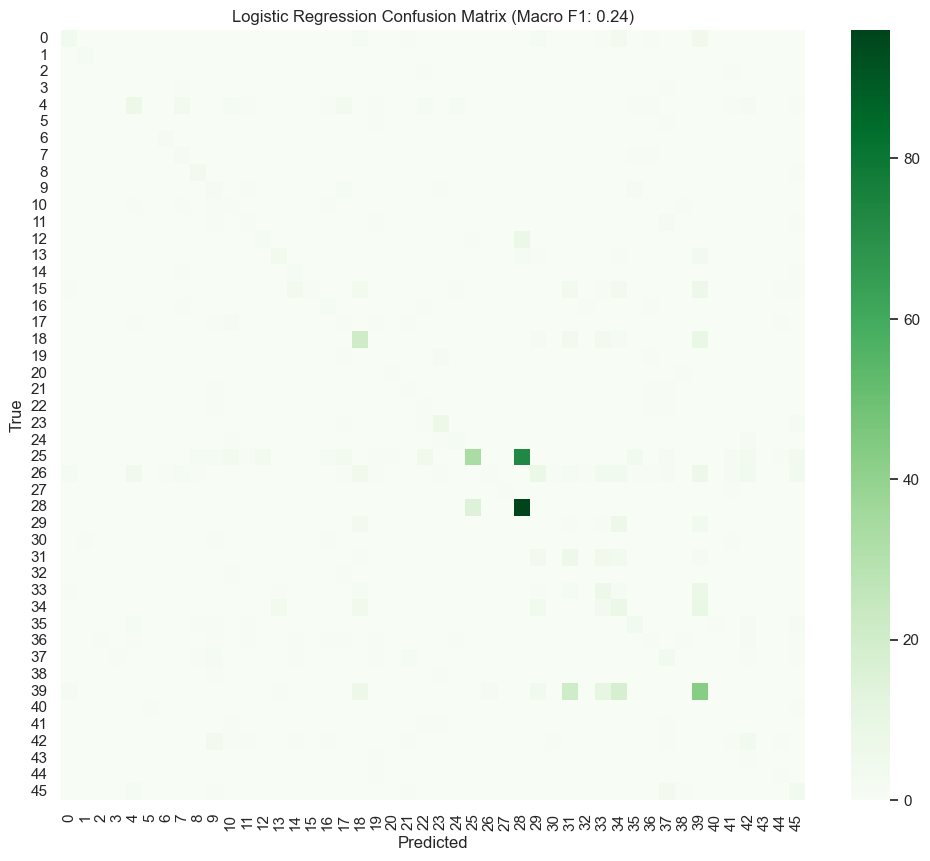

In [9]:
# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap='Greens', fmt='d')
plt.title(f'Logistic Regression Confusion Matrix (Macro F1: {macro_f1:.2f})')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig(f'{reports_dir}/lr_confusion_matrix.png')
plt.show()

In [10]:
# Save Top Errors
results = pd.DataFrame({'True': y_val, 'Predicted': y_pred})
results['True_Label'] = results['True'].map(id_to_label)
results['Pred_Label'] = results['Predicted'].map(id_to_label)

errors = results[results['True'] != results['Predicted']]
errors.to_csv(f'{reports_dir}/lr_errors.csv', index=False)
print(f"Errors saved to {reports_dir}/lr_errors.csv")
print("Total Errors:", len(errors))

Errors saved to round1/reports/lr_errors.csv
Total Errors: 545
